# VisDrone -- : Dataset Exploration

**Objective**: Understand the VisDrone dataset in depth

This notebook covers:
- Dataset statistics (image & annotation counts per split)
- Original class distribution across the full dataset
- Class merging strategy: `pedestrian + people -> person`, `car -> car`
- Sample image visualizations with bounding boxes
- Challenge analysis: small objects, occlusion, class imbalance



---
## 1. Setup & Installation

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from collections import Counter, defaultdict
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Configuration -- Paths & Class Mapping

In [2]:
# Dataset root (relative to this notebook)
DATASET_ROOT = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'

SPLITS = {
    'train': {
        'images': os.path.join(DATASET_ROOT, 'VisDrone2019-DET-train', 'images'),
        'labels': os.path.join(DATASET_ROOT, 'VisDrone2019-DET-train', 'labels'),
    },
    'val': {
        'images': os.path.join(DATASET_ROOT, 'VisDrone2019-DET-val', 'images'),
        'labels': os.path.join(DATASET_ROOT, 'VisDrone2019-DET-val', 'labels'),
    },
    'test-dev': {
        'images': os.path.join(DATASET_ROOT, 'VisDrone2019-DET-test-dev', 'images'),
        'labels': os.path.join(DATASET_ROOT, 'VisDrone2019-DET-test-dev', 'labels'),
    },
}

# Original 10-class mapping
ORIGINAL_CLASSES = [
    'pedestrian', 'people', 'bicycle', 'car', 'van',
    'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor'
]

# Target class merge mapping (original_id -> new_id)
# 0: pedestrian -> person (0)
# 1: people     -> person (0)
# 3: car        -> car    (1)
# All others are ignored / filtered out
TARGET_MERGE = {
    0: (0, 'person'),   # pedestrian
    1: (0, 'person'),   # people
    3: (1, 'car'),      # car
}
TARGET_CLASS_NAMES = ['person', 'car']
TARGET_COLORS = {'person': (0.2, 0.6, 1.0), 'car': (1.0, 0.5, 0.1)}

print('Config set. Dataset root:', os.path.abspath(DATASET_ROOT))
for split, paths in SPLITS.items():
    img_exists = os.path.exists(paths['images'])
    lbl_exists = os.path.exists(paths['labels'])
    print(f"  [{split}] images: {'OK' if img_exists else 'MISSING'}  labels: {'OK' if lbl_exists else 'MISSING'}")

Config set. Dataset root: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
  [train] images: OK  labels: OK
  [val] images: OK  labels: OK
  [test-dev] images: OK  labels: OK


---
## 3. Dataset Statistics

In [3]:
# Image & Annotation Counts per Split
stats = []

for split_name, paths in SPLITS.items():
    img_dir = paths['images']
    lbl_dir = paths['labels']

    img_count = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    lbl_count = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0

    stats.append({'Split': split_name, 'Images': img_count, 'Label Files': lbl_count})

df_stats = pd.DataFrame(stats)
print('=== Dataset Split Summary ===')
print(df_stats.to_string(index=False))

=== Dataset Split Summary ===
   Split  Images  Label Files
   train    6471         6471
     val     548          548
test-dev    1610         1610


In [4]:
# Full Class Distribution (Training Set)
class_counter = Counter()
total_boxes = 0

train_lbl_dir = SPLITS['train']['labels']
label_files = [f for f in os.listdir(train_lbl_dir) if f.endswith('.txt')]

for fname in tqdm(label_files, desc='Scanning train labels'):
    fpath = os.path.join(train_lbl_dir, fname)
    with open(fpath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                class_counter[cls_id] += 1
                total_boxes += 1

print(f'\nTotal bounding boxes in train: {total_boxes:,}')
print('\nPer-class breakdown:')
for cls_id, count in sorted(class_counter.items()):
    cls_name = ORIGINAL_CLASSES[cls_id] if cls_id < len(ORIGINAL_CLASSES) else f'unknown_{cls_id}'
    print(f'  [{cls_id}] {cls_name:<20} : {count:>8,}  ({count/total_boxes*100:.1f}%)')

Scanning train labels: 100%|██████████| 6471/6471 [00:31<00:00, 207.88it/s]


Total bounding boxes in train: 343,205

Per-class breakdown:
  [0] pedestrian           :   79,337  (23.1%)
  [1] people               :   27,059  (7.9%)
  [2] bicycle              :   10,480  (3.1%)
  [3] car                  :  144,867  (42.2%)
  [4] van                  :   24,956  (7.3%)
  [5] truck                :   12,875  (3.8%)
  [6] tricycle             :    4,812  (1.4%)
  [7] awning-tricycle      :    3,246  (0.9%)
  [8] bus                  :    5,926  (1.7%)
  [9] motor                :   29,647  (8.6%)


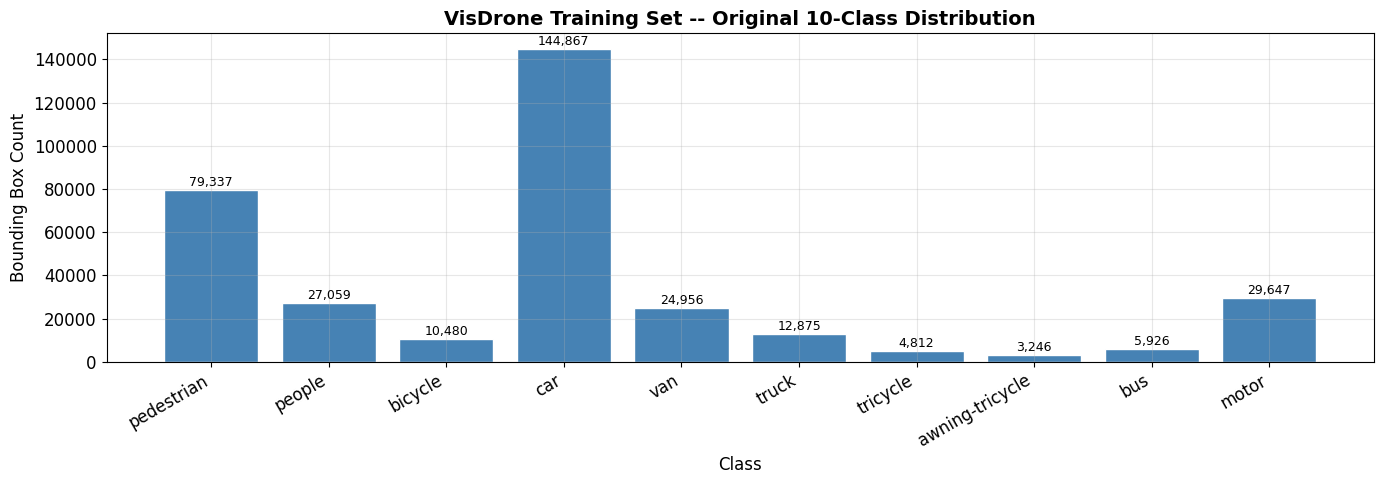

Saved to results/class_distribution_original.png


In [5]:
# Bar Chart: Original Class Distribution
labels = [ORIGINAL_CLASSES[i] if i < len(ORIGINAL_CLASSES) else f'cls_{i}'
          for i in sorted(class_counter.keys())]
counts = [class_counter[i] for i in sorted(class_counter.keys())]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(labels, counts, color='steelblue', edgecolor='white')
ax.set_title('VisDrone Training Set -- Original 10-Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Bounding Box Count')
ax.set_xlabel('Class')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution_original.png', dpi=150)
plt.show()
print('Saved to results/class_distribution_original.png')

---
## 4. Class Merging Analysis

In [6]:
# Merged Class Distribution (person & car only)
merged_counter = Counter()

for cls_id, count in class_counter.items():
    if cls_id in TARGET_MERGE:
        new_id, new_name = TARGET_MERGE[cls_id]
        merged_counter[new_name] += count

print('=== After Class Merging ===')
for cls_name, count in merged_counter.items():
    print(f'  {cls_name:<10}: {count:>8,}')

total_merged = sum(merged_counter.values())
ratio = merged_counter.get('person', 0) / (merged_counter.get('car', 1))
print(f'\n  Total boxes kept : {total_merged:,}')
print(f'  Boxes discarded  : {total_boxes - total_merged:,} ({(total_boxes-total_merged)/total_boxes*100:.1f}%)')
print(f'  Person : Car ratio: {ratio:.1f} : 1')

=== After Class Merging ===
  car       :  144,867
  person    :  106,396

  Total boxes kept : 251,263
  Boxes discarded  : 91,942 (26.8%)
  Person : Car ratio: 0.7 : 1


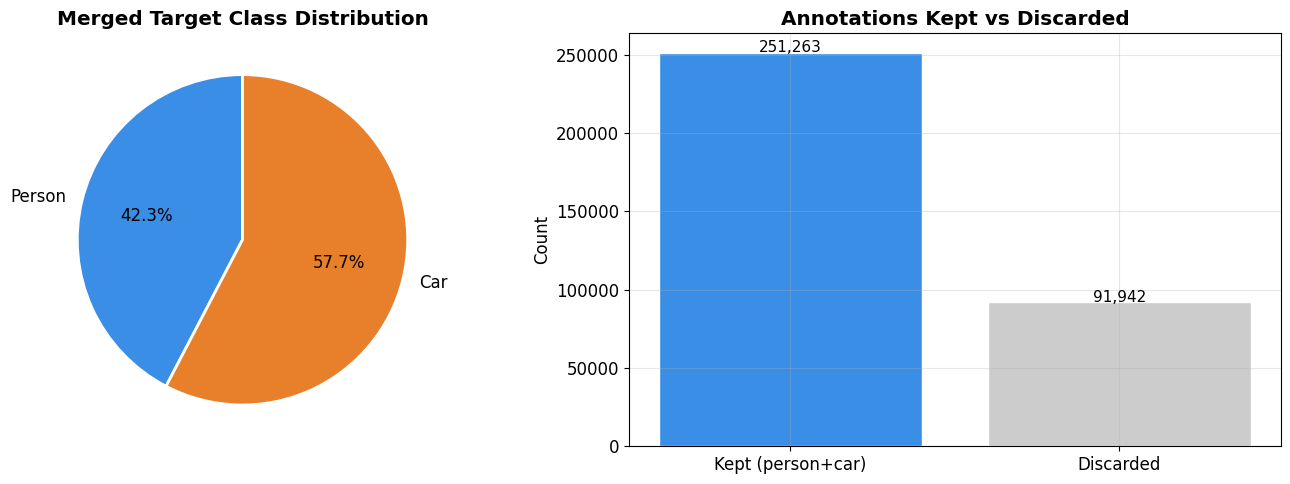

Saved to results/class_merge_analysis.png


In [7]:
# Pie Chart: Merged class balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: merged
axes[0].pie(
    [merged_counter.get('person', 0), merged_counter.get('car', 0)],
    labels=['Person', 'Car'],
    autopct='%1.1f%%',
    colors=['#3A8EE6', '#E87F2B'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Merged Target Class Distribution', fontweight='bold')

# Bar: kept vs discarded
kept = total_merged
discarded = total_boxes - total_merged
axes[1].bar(['Kept (person+car)', 'Discarded'], [kept, discarded],
            color=['#3A8EE6', '#CCCCCC'], edgecolor='white')
axes[1].set_title('Annotations Kept vs Discarded', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([kept, discarded]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/class_merge_analysis.png', dpi=150)
plt.show()
print('Saved to results/class_merge_analysis.png')

---
## 5. Bounding Box Size Analysis (Small Object Challenge)

In [8]:
# Analyse bounding box sizes to understand small object challenges
# YOLO label format: class cx cy w h (all normalized 0-1)
box_widths  = []
box_heights = []
box_areas   = []

IMG_W, IMG_H = 1920, 1080   # VisDrone typical resolution

for fname in tqdm(label_files, desc='Analysing bbox sizes'):
    fpath = os.path.join(train_lbl_dir, fname)
    with open(fpath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                if cls_id in TARGET_MERGE:
                    w_norm = float(parts[3])
                    h_norm = float(parts[4])
                    w_px = w_norm * IMG_W
                    h_px = h_norm * IMG_H
                    area_px = w_px * h_px
                    box_widths.append(w_px)
                    box_heights.append(h_px)
                    box_areas.append(area_px)

box_areas = np.array(box_areas)
print(f'Total target boxes analysed : {len(box_areas):,}')
print(f'Median bbox area (px^2)     : {np.median(box_areas):.1f}')
print(f'Mean bbox area   (px^2)     : {np.mean(box_areas):.1f}')
print(f'Boxes < 32x32 (tiny)        : {(box_areas < 1024).mean()*100:.1f}%')
print(f'Boxes < 64x64 (small)       : {(box_areas < 4096).mean()*100:.1f}%')

Analysing bbox sizes: 100%|██████████| 6471/6471 [00:04<00:00, 1596.82it/s]

Total target boxes analysed : 251,263
Median bbox area (px^2)     : 857.1
Mean bbox area   (px^2)     : 2838.5
Boxes < 32x32 (tiny)        : 54.8%
Boxes < 64x64 (small)       : 83.1%


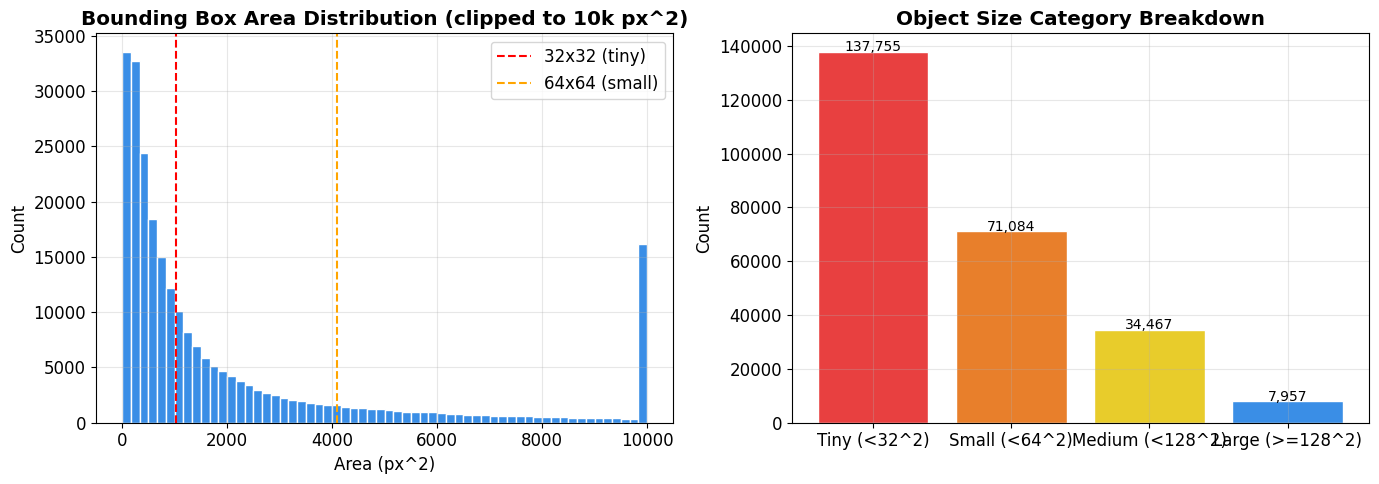

Saved to results/bbox_size_analysis.png


In [9]:
# Histogram: bbox area distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.clip(box_areas, 0, 10000), bins=60, color='#3A8EE6', edgecolor='white')
axes[0].axvline(1024, color='red', linestyle='--', label='32x32 (tiny)')
axes[0].axvline(4096, color='orange', linestyle='--', label='64x64 (small)')
axes[0].set_title('Bounding Box Area Distribution (clipped to 10k px^2)', fontweight='bold')
axes[0].set_xlabel('Area (px^2)')
axes[0].set_ylabel('Count')
axes[0].legend()

size_bins = ['Tiny (<32^2)', 'Small (<64^2)', 'Medium (<128^2)', 'Large (>=128^2)']
size_counts = [
    (box_areas < 1024).sum(),
    ((box_areas >= 1024) & (box_areas < 4096)).sum(),
    ((box_areas >= 4096) & (box_areas < 16384)).sum(),
    (box_areas >= 16384).sum()
]
axes[1].bar(size_bins, size_counts, color=['#E84040', '#E87F2B', '#E8CC2B', '#3A8EE6'], edgecolor='white')
axes[1].set_title('Object Size Category Breakdown', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(size_counts):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/bbox_size_analysis.png', dpi=150)
plt.show()
print('Saved to results/bbox_size_analysis.png')

---
## 6. Sample Image Visualizations

In [10]:
def draw_yolo_labels(img_path, label_path, class_names, color_map):
    """Draw YOLO bounding boxes on an image for the target merged classes."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(img)

    person_count = 0
    car_count = 0

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    if cls_id not in TARGET_MERGE:
                        continue
                    new_id, cls_name = TARGET_MERGE[cls_id]
                    cx, cy, w, h = map(float, parts[1:])
                    x1 = (cx - w / 2) * W
                    y1 = (cy - h / 2) * H
                    bw = w * W
                    bh = h * H
                    color = TARGET_COLORS[cls_name]
                    rect = patches.Rectangle((x1, y1), bw, bh,
                                             linewidth=1.5,
                                             edgecolor=color,
                                             facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 3, cls_name, fontsize=7,
                            color='white',
                            bbox=dict(boxstyle='round,pad=0.1', fc=color, alpha=0.8))
                    if cls_name == 'person':
                        person_count += 1
                    else:
                        car_count += 1

    ax.set_title(f'{os.path.basename(img_path)} -- Persons: {person_count}  |  Cars: {car_count}',
                 fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    return fig

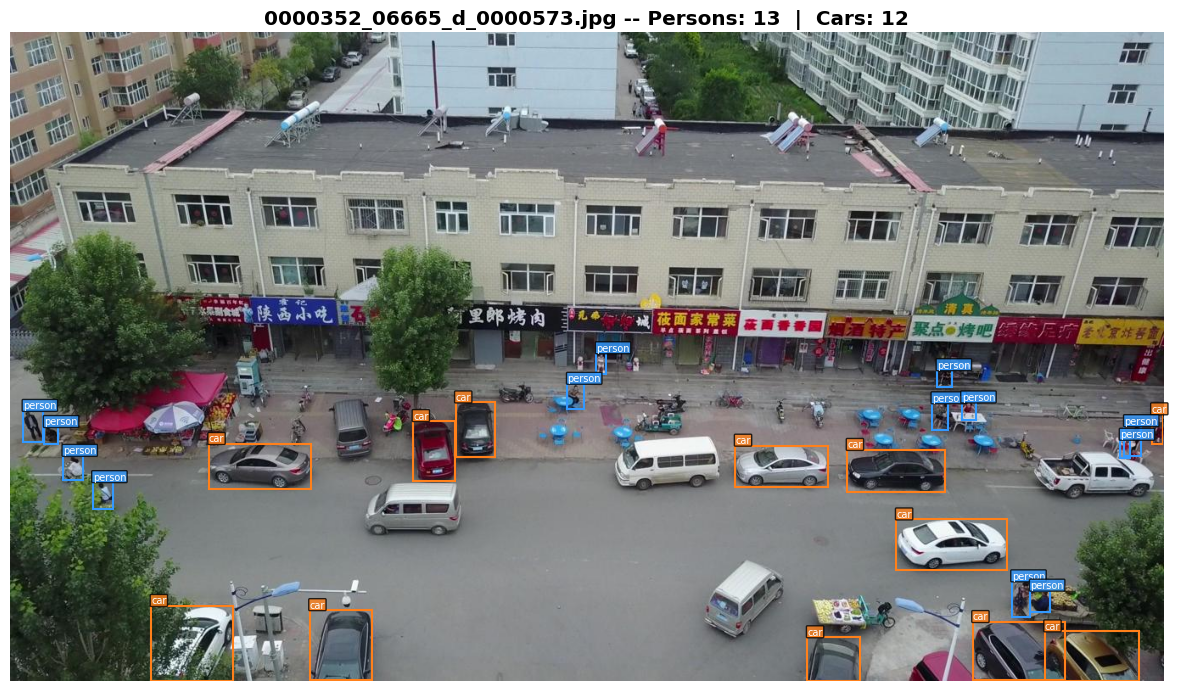

Saved: /kaggle/working/sample_vis_1.png


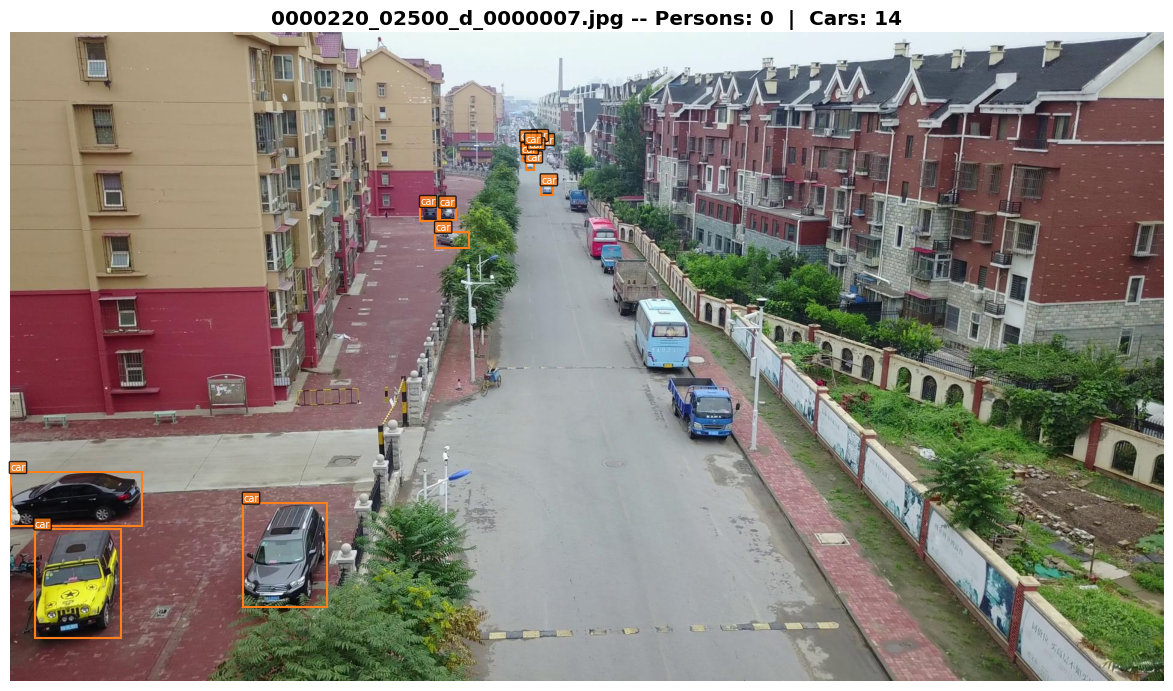

Saved: /kaggle/working/sample_vis_2.png


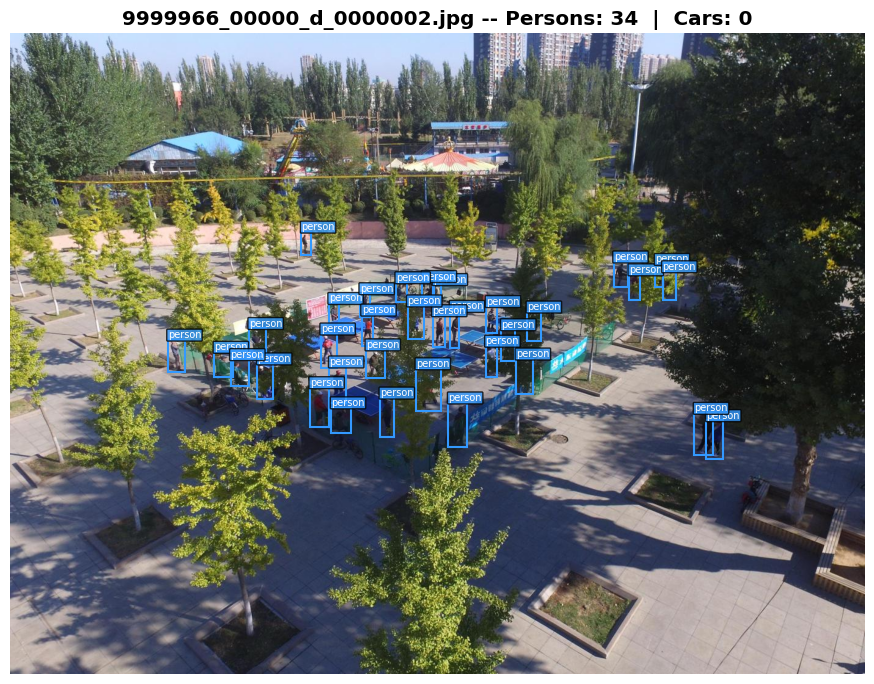

Saved: /kaggle/working/sample_vis_3.png


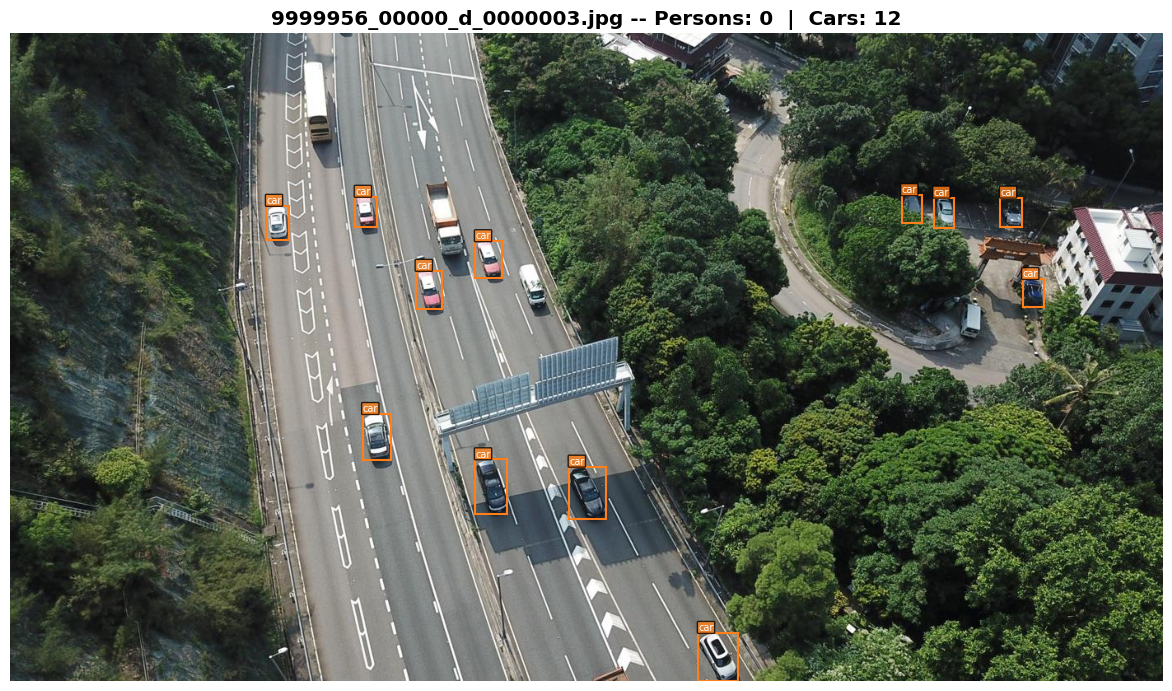

Saved: /kaggle/working/sample_vis_4.png


In [11]:
# Visualize 4 random training images with merged annotations
os.makedirs('/kaggle/working', exist_ok=True)

train_img_dir = SPLITS['train']['images']
train_lbl_dir = SPLITS['train']['labels']

img_files = [f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
samples = random.sample(img_files, min(4, len(img_files)))

for i, img_file in enumerate(samples):
    img_path = os.path.join(train_img_dir, img_file)
    label_path = os.path.join(train_lbl_dir, os.path.splitext(img_file)[0] + '.txt')
    fig = draw_yolo_labels(img_path, label_path, TARGET_CLASS_NAMES, TARGET_COLORS)
    if fig:
        save_path = f'/kaggle/working/sample_vis_{i+1}.png'
        fig.savefig(save_path, dpi=120)
        plt.show()
        print(f'Saved: {save_path}')

---
## 7. Challenge Summary

In [12]:
print('=' * 70)
print('VisDrone -- Computed Challenge Analysis')
print('=' * 70)

# Recompute all metrics locally (no cross-cell dependencies)
_tiny        = float((box_areas < 1024).mean() * 100)
_small       = float((box_areas < 4096).mean() * 100)
_ts_combined = _small
_median      = float(np.median(box_areas))

_sc = [
    int((box_areas < 1024).sum()),
    int(((box_areas >= 1024) & (box_areas < 4096)).sum()),
    int(((box_areas >= 4096) & (box_areas < 16384)).sum()),
    int((box_areas >= 16384).sum()),
]
_sl       = ['Tiny', 'Small', 'Medium', 'Large']
_dominant = _sl[int(np.argmax(_sc))]

_person  = merged_counter.get('person', 0)
_car     = max(merged_counter.get('car', 1), 1)
_ratio   = _person / _car

_discard = (total_boxes - total_merged) / max(total_boxes, 1) * 100

_train_row = df_stats[df_stats['Split'] == 'train']
_n_imgs    = int(_train_row['Images'].values[0]) if len(_train_row) else 0

# ── Challenge 1: Small Object Severity ───────────────────────────────────────
print(f'\n[1] Small Object Severity')
print(f'    Dominant size   : {_dominant}')
print(f'    Tiny (<32x32)   : {_tiny:.1f}%')
print(f'    Tiny + Small    : {_ts_combined:.1f}%')
print(f'    Median area     : {_median:.0f} px^2  (~{_median**0.5:.0f}x{_median**0.5:.0f} px)')
if _tiny > 40:
    print('    Severity        : HIGH')
    print('    Action          : imgsz=1280 mandatory, consider SAHI tile inference')
elif _tiny > 20:
    print('    Severity        : MEDIUM')
    print('    Action          : imgsz=1280, mosaic=1.0')
else:
    print('    Severity        : LOW')
    print('    Action          : Test imgsz=640 and 1280')

# ── Challenge 2: Class Imbalance ─────────────────────────────────────────────
print(f'\n[2] Class Imbalance')
print(f'    Person          : {_person:,}')
print(f'    Car             : {_car:,}')
print(f'    Ratio           : {_ratio:.1f}:1 (person:car)')
if _ratio > 10:
    print('    Severity        : SEVERE -- apply class weights and weighted sampling')
elif _ratio > 5:
    print('    Severity        : MODERATE -- focal loss sufficient, monitor per-class mAP')
else:
    print('    Severity        : MILD -- no special weighting needed')

# ── Challenge 3: Annotation Discard Rate ─────────────────────────────────────
print(f'\n[3] Annotation Discard After Merge')
print(f'    Discarded       : {_discard:.1f}%')
if _discard > 60:
    print('    Note            : High -- consider adding van/truck classes later')
elif _discard > 30:
    print('    Note            : Moderate -- 2-class setup is appropriate to start')
else:
    print('    Note            : Low -- class mapping is efficient')

# ── Challenge 4: Dataset Volume ──────────────────────────────────────────────
print(f'\n[4] Dataset Volume')
print(f'    Train images    : {_n_imgs:,}')
if _n_imgs < 3000:
    print('    Action          : Heavy augmentations -- mosaic=1.0, copy_paste=0.3, mixup=0.1')
elif _n_imgs < 8000:
    print('    Action          : Standard augmentations sufficient')
else:
    print('    Action          : Good volume -- focus on hyperparameter tuning')

# ── Challenge 5: Tracker Recommendation (knowledge-driven) ───────────────────
# Logic sourced from object_tracking_method_detailed.md
print(f'\n[5] Tracker Recommendation')

# DeepSORT: appearance model fails on tiny objects (feature impoverishment)
_deepsort_ok = _tiny < 20
print(f'    DeepSORT        : {"AVOID -- appearance model unreliable at " + str(round(_tiny,1)) + "% tiny objects" if not _deepsort_ok else "Viable at this object scale"}')

# ByteTrack: hierarchical low-score mining recovers blurred/occluded targets
# VisDrone benchmark: MOTA=31.3%, IDF1=49.3%, IDSW=1327
print(f'    ByteTrack       : Recommended baseline (VisDrone: MOTA=31.3%, IDF1=49.3%)')
print(f'                      Recovers low-confidence detections via secondary association')

# BoT-SORT: Camera Motion Compensation (CMC) stabilizes ego-motion errors
print(f'    BoT-SORT        : Preferred for moving drone platforms (has CMC)')
print(f'                      Same MOTA as ByteTrack on VisDrone but better identity stability')

# OC-SORT: retroactive Kalman smoothing for non-linear motion / heavy occlusion
# ByteTrack ADE is 260% higher than OC-SORT on non-linear motion sequences
if _ts_combined > 60:
    print(f'    OC-SORT         : Strongly recommended -- {_ts_combined:.0f}% tiny+small causes heavy occlusion')
    print(f'                      Retroactive re-update corrects Kalman drift after reappearance')
else:
    print(f'    OC-SORT         : Optional -- use for agile drone maneuver sequences')

# Final priority order
print(f'\n    Priority order for this dataset:')
if _tiny > 30 and _ts_combined > 60:
    print(f'    1. BoT-SORT  -- CMC + hierarchical, best identity on dense small-object scenes')
    print(f'    2. OC-SORT   -- non-linear motion and prolonged occlusion resilience')
    print(f'    3. ByteTrack -- fastest, strong recall via low-score mining')
    print(f'    4. DeepSORT  -- NOT recommended ({_tiny:.0f}% tiny objects degrade appearance model)')
elif _tiny > 20:
    print(f'    1. ByteTrack -- best speed-accuracy tradeoff, recovers low-conf targets')
    print(f'    2. BoT-SORT  -- better accuracy if compute budget allows')
    print(f'    3. OC-SORT   -- for non-linear or agile drone sequences')
    print(f'    4. DeepSORT  -- marginal; avoid if object scale drops further')
else:
    print(f'    1. ByteTrack -- standard baseline')
    print(f'    2. BoT-SORT  -- better identity stability')
    print(f'    3. OC-SORT   -- occlusion resilience')
    print(f'    4. DeepSORT  -- viable at this object scale')

# ── Final Training Config Summary ─────────────────────────────────────────────
print('\n' + '=' * 70)
print('    Training Recommendations')
print('=' * 70)
print(f'    imgsz           : {"1280" if _tiny > 20 else "640 (test both)"}')
print(f'    batch (T4)      : {8 if _tiny > 20 else 16}')
print(f'    Class weights   : {"Yes" if _ratio > 5 else "No"}')
print(f'    Augmentation    : {"Heavy (mosaic=1.0, copy_paste=0.3)" if _n_imgs < 5000 else "Standard"}')
print('=' * 70)


VisDrone -- Computed Challenge Analysis

[1] Small Object Severity
    Dominant size   : Tiny
    Tiny (<32x32)   : 54.8%
    Tiny + Small    : 83.1%
    Median area     : 857 px^2  (~29x29 px)
    Severity        : HIGH
    Action          : imgsz=1280 mandatory, consider SAHI tile inference

[2] Class Imbalance
    Person          : 106,396
    Car             : 144,867
    Ratio           : 0.7:1 (person:car)
    Severity        : MILD -- no special weighting needed

[3] Annotation Discard After Merge
    Discarded       : 26.8%
    Note            : Low -- class mapping is efficient

[4] Dataset Volume
    Train images    : 6,471
    Action          : Standard augmentations sufficient

[5] Tracker Recommendation
    DeepSORT        : AVOID -- appearance model unreliable at 54.8% tiny objects
    ByteTrack       : Recommended baseline (VisDrone: MOTA=31.3%, IDF1=49.3%)
                      Recovers low-confidence detections via secondary association
    BoT-SORT        : Preferred 